[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nursnaaz/zero-to-genai-engineer/blob/main/11_LangGraph/notebooks/03_multi_agent_orchestrator.ipynb)


# Multi-Agent Orchestrator — a helpdesk company

**Session 11, notebook 3.** Run top to bottom.

## The one problem this notebook solves

Notebook 01 gave you **one** agent on **one** graph (loop, branch, tools).
Notebook 02 let that graph **freeze** so a human can type yes or no.

What was **MISSING:** one person cannot do policy + public web + SQL + ticket
writes well. A real helpdesk is a **company**: desks, then people.

We do **not** rebuild hybrid search, SQLite, or FastMCP. We start the Module 10
helpdesk and **route** work.

## The word "graph" — read this once, then stop worrying

In LangGraph, a **graph** is just boxes and arrows that can loop. That word
will appear again and again because **we nest the same idea**:

| Everyday word | LangGraph object | What it looks like |
|---|---|---|
| A **person** | `rag_agent`, `sql_agent`, … | tiny loop: model ⇄ tools |
| A **desk** | `knowledge_team`, `ops_team` | a manager + two people |
| The **company** | `graph` (the product) | a CEO + two desks |

All three are compiled graphs. The people drawings look almost identical on
purpose — they are the same ReAct loop from notebook 01. The **new** lesson is
who reports to whom, not a new kind of box.

We will compile the company **once** and draw **one** picture (the CEO view).
Then we ask questions and watch the path. We will not dump seven PNGs.

## Supervisor vs hierarchical (same idea, two floors)

- **Supervisor** = a manager. Specialists do the work and report back.
- **Hierarchical** = a manager **of** managers. CEO → desk lead → person.

This product is hierarchical. We did **not** ship swarm (peers, no manager).
That contrast is optional at the end.

```
CEO          top_supervisor
 ├── Knowledge desk     rag_agent (policy) + search_agent (web)
 └── Operations desk    sql_agent (reads)  + ticket_agent (writes — you approve)
```

## How to self-study

1. Run **one step**. Read **What to look at**. Then go on.
2. After a question, look at the printed path (`knowledge_team → rag_agent`),
   not the PNG.
3. The write demo **waits for you**. Type `yes` or `no`.

## Roadmap

| Step | What you will do |
|---|---|
| 1 | Company picture — who reports to whom |
| 2 | Start the Module 10 helpdesk (do not rebuild it) |
| 3 | Split tools into four jobs |
| 4 | Compile the company. Draw the CEO view once |
| 5 | Three questions — watch which desk ran |
| 6 | You approve or reject a ticket note |
| 7 | Two `thread_id`s — chat memory does not leak |
| 8 | *(optional)* Swarm exists — we are not shipping it |
| 9 | Streamlit app |


---
# Setup

Install packages, then load your API key. After a **fresh** install:
**Kernel → Restart Kernel**, then run from here again.

The version pins are in quotes on purpose. Without quotes, zsh reads `>=0.6`
as a file redirect.


In [23]:
%pip install -q "langgraph>=0.6" "langgraph-supervisor>=0.0.27" "langchain>=1.0" \
    langchain-openai langchain-core langchain-mcp-adapters mcp python-dotenv \
    nest_asyncio tavily-python ddgs

import importlib.metadata
print("langgraph            :", importlib.metadata.version("langgraph"))
print("langchain            :", importlib.metadata.version("langchain"))
print("langgraph-supervisor :", importlib.metadata.version("langgraph-supervisor"))



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
langgraph            : 1.1.3
langchain            : 1.2.13
langgraph-supervisor : 0.0.31


In [24]:
import warnings, os, sys
warnings.filterwarnings("ignore")

from pathlib import Path
from dotenv import load_dotenv

here = Path.cwd().resolve()
env_files = []
for folder in [here, *here.parents]:
    for candidate in (folder / ".env", folder / "10_RAG" / ".env"):
        if candidate.is_file() and candidate not in env_files:
            env_files.append(candidate)
            load_dotenv(candidate, override=False)

print("cwd            :", here)
print("Loaded .env    :", [str(p) for p in env_files] or "NONE FOUND")
print("OPENAI_API_KEY :", "set" if os.getenv("OPENAI_API_KEY") else "MISSING")
print("TAVILY_API_KEY :", "set" if os.getenv("TAVILY_API_KEY") else "not set (will use ddgs)")


cwd            : /Users/mohamednoordeenalaudeen/Documents/GenAI-2026/zero-to-genai-engineer/11_LangGraph/notebooks
Loaded .env    : ['/Users/mohamednoordeenalaudeen/Documents/GenAI-2026/zero-to-genai-engineer/10_RAG/.env', '/Users/mohamednoordeenalaudeen/Documents/GenAI-2026/.env']
OPENAI_API_KEY : set
TAVILY_API_KEY : not set (will use ddgs)


In [25]:
def show_graph(compiled, title=""):
    """Draw ONE compiled LangGraph (node list + optional PNG).

    We use this for the company view — not for every person.
    Supervisor arrows are often hidden in the PNG. The node list is enough.
    """
    if title:
        print("=" * 64)
        print(title)
        print("=" * 64)
    g = compiled.get_graph()
    print("Boxes on this floor:", [n for n in g.nodes])
    print()
    print(g.draw_mermaid())
    try:
        from IPython.display import Image, display
        display(Image(g.draw_mermaid_png()))
    except Exception as e:
        print("PNG skipped. The text diagram is enough.", e)


# Load graph.py from this repo (not a random package named "graph").
ORCH_DIR = next(
    (p / "11_LangGraph" / "multi_agent_orchestrator"
     for p in [here, *here.parents]
     if (p / "11_LangGraph" / "multi_agent_orchestrator" / "graph.py").is_file()),
    Path.cwd().parent / "multi_agent_orchestrator",
)
print("Product code:", ORCH_DIR / "graph.py")


Product code: /Users/mohamednoordeenalaudeen/Documents/GenAI-2026/zero-to-genai-engineer/11_LangGraph/multi_agent_orchestrator/graph.py


---
# Step 1 of 9 — Who reports to whom

**In one sentence:** we ship a **hierarchical supervisor** — a CEO who talks
to two desk leads, who each talk to two people.


Think of a company, not a library of patterns.


> **Diagram:** Run the next cell — matplotlib renders it (notebooks cannot draw Mermaid text).


| Floor | Everyday name | Object you will compile |
|---|---|---|
| 0 | Person | `create_agent` — `rag_agent`, `search_agent`, `sql_agent`, `ticket_agent` |
| 1 | Desk lead | `create_supervisor` of two people — `knowledge_team`, `ops_team` |
| 2 | CEO | `create_supervisor` of two desks — this is the product |

Other LangGraph team shapes exist. **We are not implementing all of them.**

| Shape | Do we ship it? |
|---|---|
| Supervisor (one manager) | Yes — each desk, and the CEO |
| Hierarchical (manager of managers) | **Yes — the product** |
| Swarm (peers, no manager) | No — optional contrast in Step 8 |
| Map-reduce (`Send`) | No — a fan-out trick, not this architecture |

If you remember only the company diagram above, you can follow the rest of the notebook.


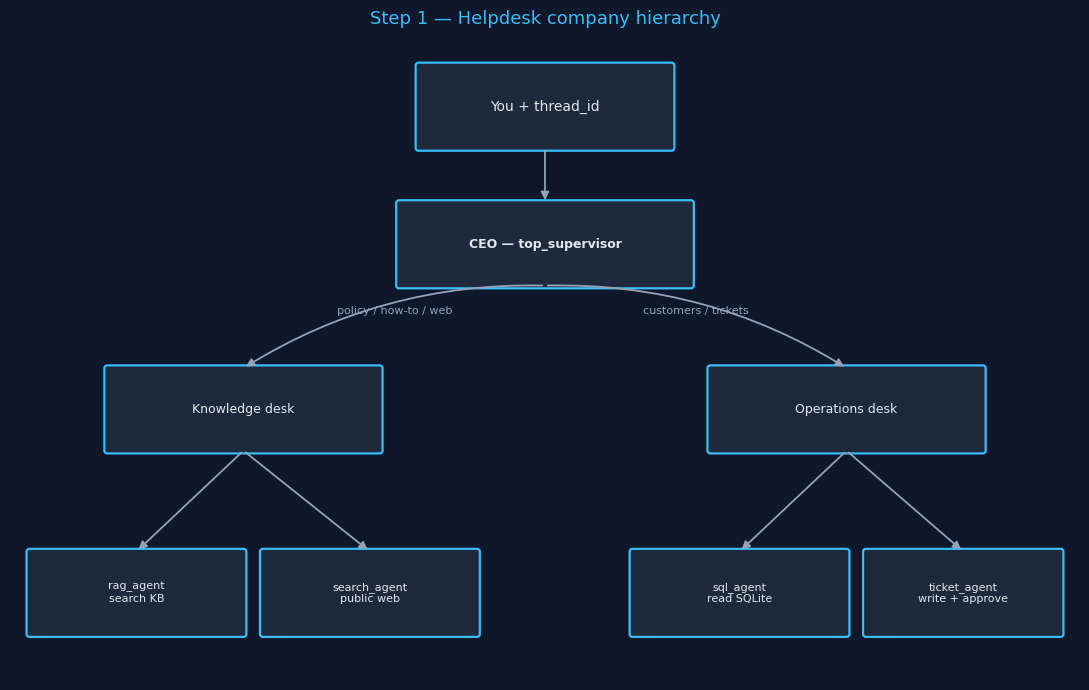

In [26]:
from _nb03_diagrams import draw_step1_company
draw_step1_company()


---
# Step 2 of 9 — Start the helpdesk. Do not rebuild it.

**In one sentence:** seed SQLite if needed, start the Module 10 MCP server,
list the tools. Today's job is **routing**, not retrieval.


In [27]:
# Always load THIS repo's graph.py (avoids a stale kernel copy / name clash).
import importlib.util

_graph_path = ORCH_DIR / "graph.py"
if not _graph_path.is_file():
    raise FileNotFoundError(f"Missing {_graph_path}. Open the course repo.")

_spec = importlib.util.spec_from_file_location("helpdesk_orch", _graph_path)
orch = importlib.util.module_from_spec(_spec)
assert _spec.loader is not None
_spec.loader.exec_module(orch)

# Names this notebook uses — if one is missing, restart the kernel and re-run Setup.
find_helpdesk_dir = orch.find_helpdesk_dir
ensure_helpdesk_db = orch.ensure_helpdesk_db
load_mcp_tools = orch.load_mcp_tools
split_mcp_tools = orch.split_mcp_tools
wrap_tool_with_approval = orch.wrap_tool_with_approval
web_search = orch.web_search
build_specialists = orch.build_specialists
build_orchestrator = orch.build_orchestrator
remember_answer_style = orch.remember_answer_style
resume_hitl = orch.resume_hitl
interrupt_payload = orch.interrupt_payload
pretty_trace_label = orch.pretty_trace_label
print("Loaded", _graph_path.name, "— resume_hitl is", callable(resume_hitl))

helpdesk_dir = find_helpdesk_dir(here)
db_path = ensure_helpdesk_db(helpdesk_dir)
print("Helpdesk :", helpdesk_dir)
print("Database :", db_path, "exists" if db_path.is_file() else "MISSING")

# Ground truth from SQLite — Jane Doe is seeded (Module 10, random.seed(42)).
import sqlite3
con = sqlite3.connect(db_path)
jane = con.execute(
    "SELECT c.id, c.plan_tier, "
    "SUM(1), SUM(t.status IN ('open','in_progress')) "
    "FROM customers c JOIN tickets t ON t.customer_id = c.id "
    "WHERE c.name = 'Jane Doe'"
).fetchone()
con.close()
print("Jane Doe  : customer_id=%s  plan=%s  tickets=%s  still-open-or-in-progress=%s" % jane)

mcp_client, mcp_tools = load_mcp_tools(helpdesk_dir)
print(f"MCP tools ({len(mcp_tools)}):")
for t in mcp_tools:
    print(" -", t.name)


Loaded graph.py — resume_hitl is True
Helpdesk : /Users/mohamednoordeenalaudeen/Documents/GenAI-2026/zero-to-genai-engineer/10_RAG/notebooks/production_mcp_agents_rag_capstone
Database : /Users/mohamednoordeenalaudeen/Documents/GenAI-2026/zero-to-genai-engineer/10_RAG/notebooks/production_mcp_agents_rag_capstone/helpdesk.db exists
Jane Doe  : customer_id=1  plan=enterprise  tickets=4  still-open-or-in-progress=2


Process group termination failed for PID 25836: [Errno 1] Operation not permitted, falling back to simple terminate


MCP tools (20):
 - create_customer
 - get_customer
 - update_customer
 - search_customers
 - list_agents
 - create_ticket
 - get_ticket
 - update_ticket_status
 - update_ticket_priority
 - assign_ticket
 - close_ticket
 - delete_ticket
 - list_tickets_by_customer
 - list_tickets_by_agent
 - add_ticket_note
 - get_ticket_notes
 - get_customer_support_history
 - get_agent_workload
 - search_knowledge_base
 - create_kb_article


**What to look at**

- About **20** tool names. `search_knowledge_base` is RAG (hybrid + rerank)
  wearing a tool schema. `get_customer` / `list_tickets_by_customer` are SQL.
  Same protocol. That is MCP.
- The server is a subprocess. Keep `mcp_client` in memory or the process dies.
- Jane Doe's counts printed above are the **answer key** for Step 5.


> **Diagram:** Run the next cell — matplotlib renders it (notebooks cannot draw Mermaid text).



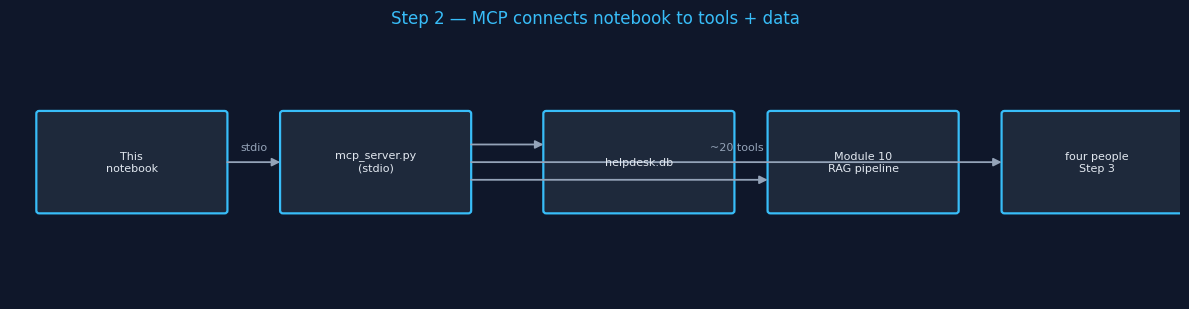

In [28]:
from _nb03_diagrams import draw_step2_mcp
draw_step2_mcp()


---
# Step 3 of 9 — Four people, four jobs

**In one sentence:** split the MCP tools by job. Ticket **writes** pause with
the same `interrupt()` as notebook 02 — via `HumanInTheLoopMiddleware`, not
inside the tool. Web search is a local `@tool`.


In [29]:
buckets = split_mcp_tools(mcp_tools)
print("RAG tools   :", [t.name for t in buckets["rag"]])
print("SQL reads   :", [t.name for t in buckets["sql"]])
print("Ticket write:", [t.name for t in buckets["ticket_write"]])

# Notebook 02 shape — useful to READ. We do NOT attach this wrap to the live
# ticket_agent: ToolNode runs tools on a thread, so interrupt() never reaches
# the checkpointer. The product uses HumanInTheLoopMiddleware instead (Step 4).
guarded = wrap_tool_with_approval(buckets["ticket_write"][0])
print("Wrapped     :", guarded.name, "| still a tool:", type(guarded).__name__)
print("Web search  :", web_search.name)
print("Live writes : HumanInTheLoopMiddleware on ticket_agent (see graph.py)")


RAG tools   : ['search_knowledge_base']
SQL reads   : ['list_tickets_by_customer', 'list_agents', 'get_customer', 'get_customer_support_history', 'get_ticket_notes', 'get_agent_workload', 'list_tickets_by_agent', 'search_customers', 'get_ticket']
Ticket write: ['create_customer', 'assign_ticket', 'add_ticket_note', 'update_ticket_priority', 'create_ticket', 'delete_ticket', 'create_kb_article', 'update_ticket_status', 'close_ticket', 'update_customer']
Wrapped     : create_customer | still a tool: StructuredTool
Web search  : web_search
Live writes : HumanInTheLoopMiddleware on ticket_agent (see graph.py)


**What to look at**

These are **people**, not four new architectures. Each person is the notebook 01
loop (model ⇄ tools) with a different toolbox.

| Person | Tools | Pauses? |
|---|---|---|
| `rag_agent` | `search_knowledge_base` | no |
| `search_agent` | `web_search` | no |
| `sql_agent` | customer / ticket / workload **reads** | no |
| `ticket_agent` | writes + a couple of reads | **yes** — every write |

RAG as a tool means: the model *chooses* to retrieve. That is different from
notebook 01's "always search then answer" chain.


> **Diagram:** Run the next cell — matplotlib renders it (notebooks cannot draw Mermaid text).


Step 4 puts a **manager** on top of these people. We will not draw four
separate PNGs — they would all look like `model ⇄ tools`.


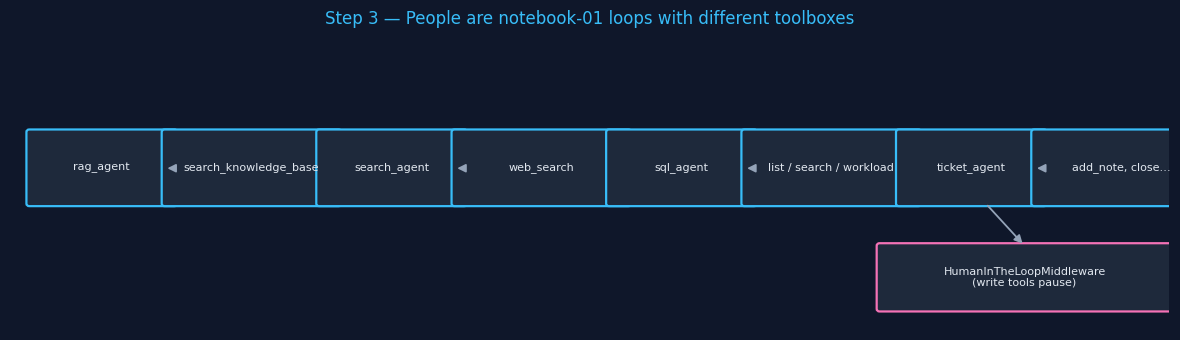

In [30]:
from _nb03_diagrams import draw_step3_tools
draw_step3_tools()


---
# Step 4 of 9 — Compile the company

**In one sentence:** two desk graphs, then a CEO graph that treats those desks
as workers. One checkpointer on the CEO so a pause inside `ticket_agent` can
resume.


In [31]:
bundle = build_orchestrator(
    helpdesk_dir=helpdesk_dir,
    mcp_client_and_tools=(mcp_client, mcp_tools),
    user_id="default-user",
)
graph = bundle["graph"]          # the COMPANY — this is what we ask questions
store = bundle["store"]
specialists = bundle["specialists"]  # the four people
teams = bundle["teams"]              # the two desks
print("People  :", list(specialists))
print("Desks   :", list(teams))
print("Company : helpdesk_orchestrator  (variable name: graph)")


People  : ['rag_agent', 'search_agent', 'sql_agent', 'ticket_agent']
Desks   : ['knowledge_team', 'ops_team']
Company : helpdesk_orchestrator  (variable name: graph)


LAYER 0 — people (each is model ⇄ tools; they look the same on purpose)

rag_agent                     policy from the knowledge base
                              boxes: ['__start__', 'model', 'tools', '__end__']

search_agent                  public web
                              boxes: ['__start__', 'model', 'tools', '__end__']

sql_agent                     SQL reads
                              boxes: ['__start__', 'model', 'tools', '__end__']

ticket_agent                  SQL writes — pauses for you
                              boxes: ['__start__', 'model', 'tools', 'HumanInTheLoopMiddleware.after_model', '__end__']

LAYER 1 — desks (a supervisor + two people)

knowledge_team                manager of rag + search
                              boxes: ['__start__', 'knowledge_supervisor', 'rag_agent', 'search_agent', '__end__']

ops_team                      manager of sql + ticket
                              boxes: ['__start__', 'ops_supervisor', 'sql_agent', 'ticket_agen

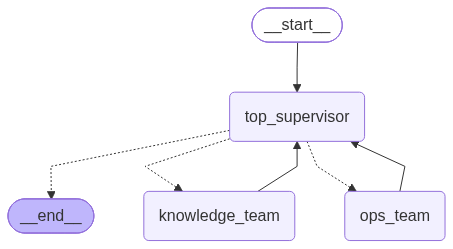

A question enters at top_supervisor, visits a desk, then a person, then comes back.


In [32]:
# Zoom table — same objects, three floors. Then ONE drawing: the CEO view.

def zoom(name, compiled, meaning):
    nodes = [n for n in compiled.get_graph().nodes]
    print(f"{name:28}  {meaning}")
    print(f"{'':28}  boxes: {nodes}\n")


print("LAYER 0 — people (each is model ⇄ tools; they look the same on purpose)\n")
zoom("rag_agent", specialists["rag_agent"], "policy from the knowledge base")
zoom("search_agent", specialists["search_agent"], "public web")
zoom("sql_agent", specialists["sql_agent"], "SQL reads")
zoom("ticket_agent", specialists["ticket_agent"], "SQL writes — pauses for you")

print("LAYER 1 — desks (a supervisor + two people)\n")
zoom("knowledge_team", teams["knowledge_team"], "manager of rag + search")
zoom("ops_team", teams["ops_team"], "manager of sql + ticket")

print("LAYER 2 — the company (this is the product)\n")
zoom("helpdesk_orchestrator", graph, "CEO of the two desks")

show_graph(graph, "CEO view — the only PNG we need")
print("A question enters at top_supervisor, visits a desk, then a person, then comes back.")


**What to look at**

You compiled **seven** objects. You drew **one** picture (the CEO). That is
enough.

- Layer 0 boxes are always `model` / `tools`. Same as notebook 01 Step 8.
- Layer 1 boxes are `*_supervisor` + two people.
- Layer 2 boxes are `top_supervisor` + two **desks** (those desks are subgraphs).

If the PNG only shows `supervisor → END`, that is a LangGraph quirk. Trust the
**box list** above and the **path** printed in Step 5.


> **Diagram:** Run the next cell — matplotlib renders it (notebooks cannot draw Mermaid text).



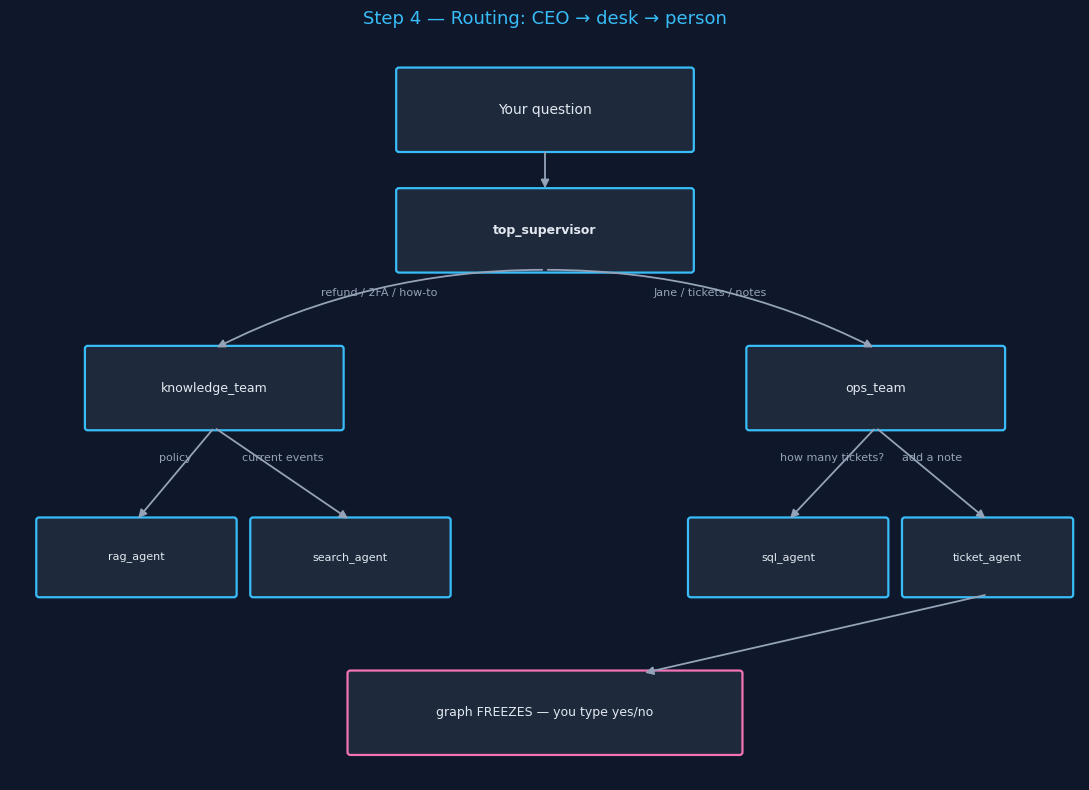

In [33]:
from _nb03_diagrams import draw_step4_routing
draw_step4_routing()


---
# Step 5 of 9 — Three questions, watch the path

Do not grade the sentence first. Grade the **path**. A good answer that went
to the wrong desk is still a miss.

The printer shows `knowledge_team → rag_agent → tools`. That is the company
walking the company diagram from Step 1.


In [34]:
from langchain_core.messages import HumanMessage
from langgraph.types import Command


def ask(question, thread_id="desk-1"):
    """Send one question through the COMPANY graph and print who ran."""
    config = {"configurable": {"thread_id": thread_id}, "recursion_limit": 50}
    print(f"\n=== Q: {question}")
    print(f"    thread={thread_id}")
    payload = None
    last_label = None
    for item in graph.stream(
        {"messages": [HumanMessage(content=question)]},
        config,
        stream_mode="updates",
        subgraphs=True,
    ):
        ns, update = item if isinstance(item, tuple) and len(item) == 2 else ((), item)
        for node_name, node_output in update.items():
            if node_name == "__interrupt__":
                if payload is None:
                    payload = node_output[0].value
                    print("  [PAUSED]", payload)
                continue
            label = pretty_trace_label(ns, node_name)
            if label != last_label:
                print(f"  [{label}]")
                last_label = label
    snap = graph.get_state(config)
    if payload is None:
        payload = interrupt_payload(snap)
        if payload is not None:
            print("  [PAUSED]", payload)
    if payload is not None:
        return config, None, payload
    messages = (snap.values or {}).get("messages") or []
    if not messages:
        print("ANSWER: (no messages on the whiteboard)")
        return config, "", None
    last = messages[-1]
    answer = getattr(last, "content", None)
    if answer is None:
        answer = str(last)
    if isinstance(answer, list):
        answer = " ".join(
            p.get("text", str(p)) if isinstance(p, dict) else str(p) for p in answer
        )
    print("ANSWER:", str(answer)[:800])
    return config, str(answer), None


In [35]:
ask(
    "Search the knowledge base and quote our cancellation and refund policy.",
    thread_id="demo-policy",
)



=== Q: Search the knowledge base and quote our cancellation and refund policy.
    thread=demo-policy
  [top_supervisor → agent]
  [top_supervisor → post_model_hook]
  [top_supervisor]
  [knowledge_team → knowledge_supervisor → agent]
  [knowledge_team → knowledge_supervisor]
  [knowledge_team → rag_agent → model]
  [knowledge_team → rag_agent → tools]
  [knowledge_team → rag_agent → model]
  [knowledge_team → rag_agent]
  [knowledge_team → knowledge_supervisor → agent]
  [knowledge_team → knowledge_supervisor]
  [knowledge_team]
  [top_supervisor → agent]
  [top_supervisor → post_model_hook]
  [top_supervisor]
  [knowledge_team → knowledge_supervisor → agent]
  [knowledge_team → knowledge_supervisor]
  [knowledge_team → rag_agent → model]
  [knowledge_team → rag_agent → tools]
  [knowledge_team → rag_agent → model]
  [knowledge_team → rag_agent]
  [knowledge_team → knowledge_supervisor → agent]
  [knowledge_team → knowledge_supervisor]
  [knowledge_team]
  [top_supervisor → agent]
  

({'configurable': {'thread_id': 'demo-policy'}, 'recursion_limit': 50},
 'Our cancellation and refund policy allows you to cancel your subscription at any time without a cancellation fee. Refunds are available only for charges made within the last 14 days; if your most recent charge falls within that window, you will receive a prorated refund automatically. Charges older than 14 days are not eligible for a refund. After cancellation, your account data is retained for 30 days in case you change your mind, after which it is permanently deleted from our systems.',
 None)

**What to look at**

Expected path:

```
you → top_supervisor → knowledge_team → rag_agent → search_knowledge_base
```

The quote should come from a KB article, not from the model inventing a policy.
If the path never mentions `rag_agent`, say that out loud — the CEO mis-routed.


In [36]:
ask("How many tickets has Jane Doe opened, and how many are still open?", thread_id="demo-sql")



=== Q: How many tickets has Jane Doe opened, and how many are still open?
    thread=demo-sql
  [top_supervisor → agent]
  [top_supervisor → post_model_hook]
  [top_supervisor]
  [ops_team → ops_supervisor → agent]
  [ops_team → ops_supervisor → post_model_hook]
  [ops_team → ops_supervisor]
  [ops_team → sql_agent → model]
  [ops_team → sql_agent → tools]
  [ops_team → sql_agent → model]
  [ops_team → sql_agent → tools]
  [ops_team → sql_agent → model]
  [ops_team → sql_agent]
  [ops_team → ops_supervisor → agent]
  [ops_team → ops_supervisor → post_model_hook]
  [ops_team → ops_supervisor]
  [ops_team]
  [top_supervisor → agent]
  [top_supervisor → post_model_hook]
  [top_supervisor]
ANSWER: Jane Doe has opened a total of 4 tickets, and 1 ticket is still open.


({'configurable': {'thread_id': 'demo-sql'}, 'recursion_limit': 50},
 'Jane Doe has opened a total of 4 tickets, and 1 ticket is still open.',
 None)

**What to look at**

Expected path:

```
you → top_supervisor → ops_team → sql_agent → search_customers / list_tickets
```

Jane's ticket counts must match Step 2's SQLite printout. This must **not** go
to `rag_agent` — her tickets are not in the policy articles.


In [37]:
# Public web — not the company KB. If TAVILY_API_KEY is missing, ddgs is used.
ask(
    "Search the public web: what is LangGraph used for? Quote a source. Two sentences.",
    thread_id="demo-web",
)



=== Q: Search the public web: what is LangGraph used for? Quote a source. Two sentences.
    thread=demo-web
  [top_supervisor → agent]
  [top_supervisor → post_model_hook]
  [top_supervisor]
  [knowledge_team → knowledge_supervisor → agent]
  [knowledge_team → knowledge_supervisor]
  [knowledge_team → search_agent → model]
  [knowledge_team → search_agent → tools]
  [knowledge_team → search_agent → model]
  [knowledge_team → search_agent]
  [knowledge_team → knowledge_supervisor → agent]
  [knowledge_team → knowledge_supervisor]
  [knowledge_team]
  [top_supervisor → agent]
  [top_supervisor → post_model_hook]
  [top_supervisor]
ANSWER: LangGraph is primarily used for creating customizable agents and orchestrating their interactions, allowing for diverse control flows and reliable execution. It integrates seamlessly with LangChain products, enhancing the capabilities of AI agents in various applications. (Source: LangGraph overview - Docs by LangChain)


({'configurable': {'thread_id': 'demo-web'}, 'recursion_limit': 50},
 'LangGraph is primarily used for creating customizable agents and orchestrating their interactions, allowing for diverse control flows and reliable execution. It integrates seamlessly with LangChain products, enhancing the capabilities of AI agents in various applications. (Source: LangGraph overview - Docs by LangChain)',
 None)

**What to look at**

Expected path:

```
you → top_supervisor → knowledge_team → search_agent → web_search
```

This must **not** go to `sql_agent`. If web search is down, the tool says so —
the model should not invent a news story.


---
# Step 6 of 9 — You are the reviewer (a write)

**In one sentence:** adding a ticket note changes the database. The graph
freezes. You type yes or no. Same four parts as notebook 02.


> **Diagram:** Run the next cell — matplotlib renders it (notebooks cannot draw Mermaid text).



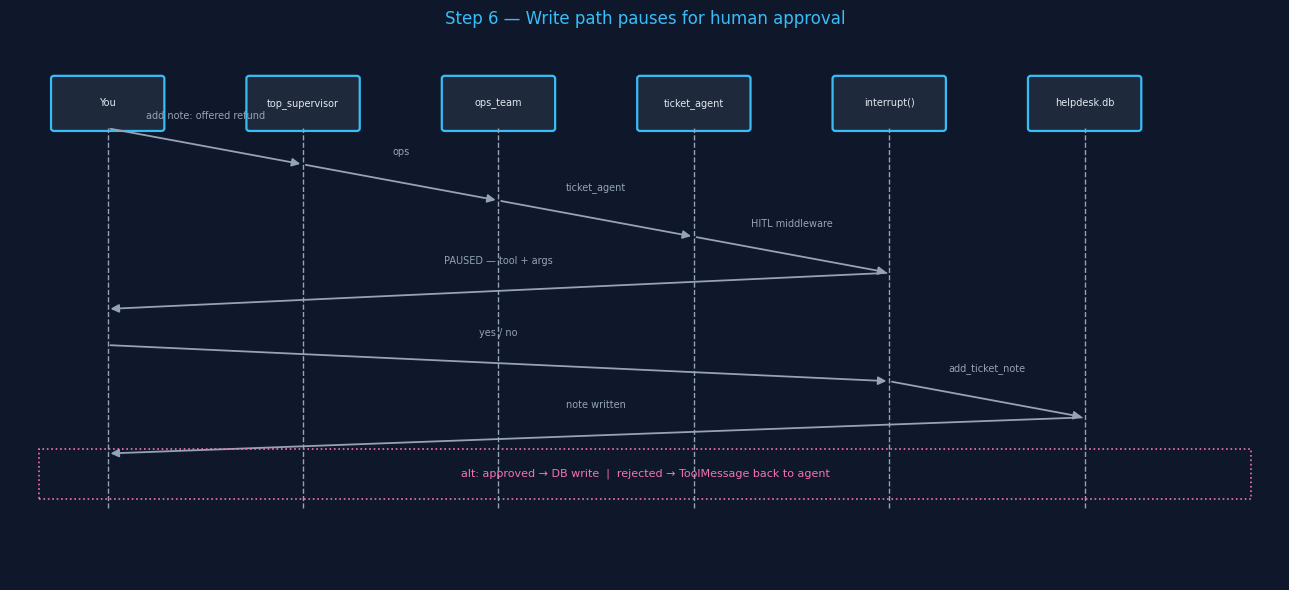

In [38]:
from _nb03_diagrams import draw_step6_hitl_sequence
draw_step6_hitl_sequence()


In [39]:
config_w, answer_w, payload_w = ask(
    "Call add_ticket_note on Jane Doe's most recent open ticket. "
    "Note text: we offered a refund. Author: classroom-demo. "
    "You must call the write tool — do not only look her up.",
    thread_id="demo-write",
)
print("Paused:", payload_w is not None)



=== Q: Call add_ticket_note on Jane Doe's most recent open ticket. Note text: we offered a refund. Author: classroom-demo. You must call the write tool — do not only look her up.
    thread=demo-write
  [top_supervisor → agent]
  [top_supervisor → post_model_hook]
  [top_supervisor]
  [ops_team → ops_supervisor → agent]
  [ops_team → ops_supervisor → post_model_hook]
  [ops_team → ops_supervisor]
  [ops_team → sql_agent → model]
  [ops_team → sql_agent → tools]
  [ops_team → sql_agent → model]
  [ops_team → sql_agent → tools]
  [ops_team → sql_agent → model]
  [ops_team → sql_agent]
  [ops_team → ops_supervisor → agent]
  [ops_team → ops_supervisor → post_model_hook]
  [ops_team → ops_supervisor]
  [ops_team → ticket_agent → model]
  [ops_team → ticket_agent → HITL]
  [ops_team → ticket_agent → tools]
  [ops_team → ticket_agent → model]
  [ops_team → ticket_agent → HITL]
  [ops_team → ticket_agent → tools]
  [ops_team → ticket_agent → model]
  [ops_team → ticket_agent → HITL]
  [ops_t

In [18]:
def human_says_yes_or_no(prompt="Approve this write? [yes/no]: ") -> bool:
    while True:
        raw = input(prompt).strip().lower()
        if raw in ("yes", "y"):
            print("→ YES. Same thread resumes.")
            return True
        if raw in ("no", "n"):
            print("→ NO. Same thread resumes.")
            return False
        print("Please type yes or no.")


if payload_w is None:
    print("This run did not pause. Read the Step 5 trace — the model may have only looked up Jane.")
    print("Re-run the write cell, or ask more bluntly: 'Add a note to ticket 1: we offered a refund.'")
else:
    print("HUMAN REVIEW")
    if isinstance(payload_w, dict):
        for k, v in payload_w.items():
            print(f"  {k}: {v}")
    else:
        print(" ", payload_w)
    approved = human_says_yes_or_no("  Write this note to the database? [yes/no]: ")
    # Middleware resume (not the notebook-02 {"approved": ...} envelope).
    resumed = graph.invoke(resume_hitl(approved), config_w)
    print("\nFinal reply:")
    last = resumed["messages"][-1]
    if hasattr(last, "pretty_print"):
        last.pretty_print()
    else:
        print(getattr(last, "content", last))



Final reply:
================================= Tool Message =================================
Name: transfer_to_ops_team

Successfully transferred to ops_team


**What to look at**

- The cell **waited**. That wait is the product.
- `yes` → the note exists (`get_ticket_notes` later will see it).
- `no` → the model must not claim it wrote.
- Resume uses the **same** `thread_id` (`demo-write`).


---
# Step 7 of 9 — Threads do not leak

**In one sentence:** a checkpointer is keyed by `thread_id`. A second desk
does not see the first desk's notes unless they are in the database *and*
that desk looks them up.


In [19]:
print("--- same thread: follow-up ---")
ask("What did we just offer Jane?", thread_id="demo-write")

print("\n--- brand-new thread: should not remember the chat ---")
ask("What did we just offer Jane?", thread_id="demo-other-desk")


--- same thread: follow-up ---

=== Q: What did we just offer Jane?
    thread=demo-write
  [top_supervisor → agent]
  [top_supervisor → post_model_hook]
  [top_supervisor]
  [ops_team → ops_supervisor → agent]
  [ops_team → ops_supervisor → post_model_hook]
  [ops_team → ops_supervisor]
  [ops_team → sql_agent → model]
  [ops_team → sql_agent]
  [ops_team → ops_supervisor → agent]
  [ops_team → ops_supervisor → post_model_hook]
  [ops_team → ops_supervisor]
  [ops_team]
  [top_supervisor → agent]
  [top_supervisor → post_model_hook]
  [top_supervisor]
  [knowledge_team → knowledge_supervisor → agent]
  [knowledge_team → knowledge_supervisor]
  [knowledge_team]
  [top_supervisor → agent]
  [top_supervisor → post_model_hook]
  [top_supervisor]
  [ops_team → ops_supervisor → agent]
  [ops_team → ops_supervisor → post_model_hook]
  [ops_team → ops_supervisor]
  [ops_team → sql_agent → model]
  [ops_team → sql_agent → tools]
  [ops_team → sql_agent → model]
  [ops_team → sql_agent → tools]

({'configurable': {'thread_id': 'demo-other-desk'}, 'recursion_limit': 50},
 "Jane has the following open and in-progress tickets:\n\n1. **Integration with our CRM broke**\n   - **Description:** Webhook stopped firing two days ago.\n   - **Status:** Open\n   - **Priority:** High\n\n2. **API returning 429 errors**\n   - **Description:** We're getting rate limited constantly since yesterday.\n   - **Status:** In Progress\n   - **Priority:** High\n\nAdditionally, she had a closed ticket regarding a password reset and another about upgrading to Enterprise, which is already her current plan. If you need more details on any specific ticket, let me know!",
 None)

**What to look at**

- `demo-write` can resolve "we" / "just" because `condense`-like history lives
  on the checkpointer (the messages list).
- `demo-other-desk` has an empty chat. It may still *look up Jane in SQL* and
  see the note **if you approved the write** — that is the database, not the
  thread. That distinction is the lesson: chat memory vs durable data.

A `Store` (Module 10 + the production app sidebar) is the third box: facts
about the *user* (answer style), not about this ticket.


> **Diagram:** Run the next cell — matplotlib renders it (notebooks cannot draw Mermaid text).



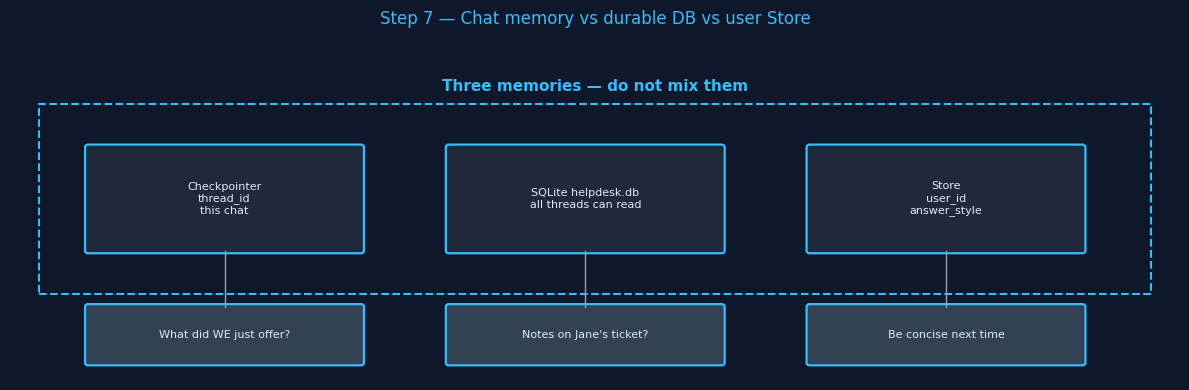

In [20]:
from _nb03_diagrams import draw_step7_memories
draw_step7_memories()


---
# Step 8 of 9 — *(optional)* Swarm exists. We are not shipping it.

Skip this step if you are tired. The helpdesk you already ran is the product.

**In one sentence:** in a swarm, people hand control to each other. There is
no CEO to audit. Faster. Easier to loop. Wrong default for a helpdesk.


Password question — billing hands off to tech (no supervisor):
[tech] I can help with login and 2FA.
Invoice question — billing keeps it:
[billing] I can help with invoices.
We will not put the helpdesk on this pattern. One mis-handoff and there is no center to inspect.
SWARM contrast — peers, no supervisor. Compare to the Layer 2 drawing.
Boxes on this floor: ['__start__', 'billing_peer', 'tech_peer', '__end__']

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__(<p>__start__</p>)
	billing_peer(billing_peer)
	tech_peer(tech_peer)
	__end__(<p>__end__</p>)
	__start__ --> billing_peer;
	billing_peer --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



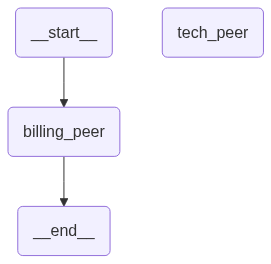

In [21]:
from langchain_core.messages import AIMessage
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.types import Command as Handoff


def billing_peer(state: MessagesState) -> Handoff:
    text = state["messages"][-1].content.lower()
    if "password" in text or "login" in text:
        return Handoff(goto="tech_peer")  # peer-to-peer — no supervisor
    return Handoff(goto=END, update={"messages": [AIMessage(content="[billing] I can help with invoices.")]})


def tech_peer(state: MessagesState) -> Handoff:
    return Handoff(goto=END, update={"messages": [AIMessage(content="[tech] I can help with login and 2FA.")]})


swarm = StateGraph(MessagesState)
swarm.add_node("billing_peer", billing_peer)
swarm.add_node("tech_peer", tech_peer)
swarm.add_edge(START, "billing_peer")
swarm_app = swarm.compile()

print("Password question — billing hands off to tech (no supervisor):")
print(swarm_app.invoke({"messages": [("user", "I cannot reset my password.")]})["messages"][-1].content)
print("Invoice question — billing keeps it:")
print(swarm_app.invoke({"messages": [("user", "My invoice looks wrong.")]})["messages"][-1].content)
print("We will not put the helpdesk on this pattern. One mis-handoff and there is no center to inspect.")
show_graph(swarm_app, "SWARM contrast — peers, no supervisor. Compare to the Layer 2 drawing.")


**What to look at**

`Command(goto="tech_peer")` is the same *object* as "go to the next node" in
notebook 02. The **shape** is different: nobody reports back to a manager.

Compare this tiny PNG to the CEO drawing in Step 4. The helpdesk has a center.
This sketch does not. We will not put ticket writes on a swarm.


---
# Step 9 of 9 — Ship it

The company you just asked is [`../multi_agent_orchestrator/graph.py`](../multi_agent_orchestrator/graph.py).
Streamlit adds a path table, a `thread_id` switcher, and Yes/No buttons for
the same pause.

```bash
cd ../multi_agent_orchestrator
pip install -r requirements.txt
python3.11 -m streamlit run app.py
```

**LangSmith** — if `LANGSMITH_API_KEY` is set (Module 10 `.env`), every turn is
a traced run. Open [smith.langchain.com](https://smith.langchain.com).

**LangGraph Studio** (graph + state + interrupts):

```bash
cd ../multi_agent_orchestrator
langgraph dev
```

Then open the Studio URL (`?baseUrl=http://127.0.0.1:2024`). Start a **new
thread** when you experiment — old refusals stay on the old thread.

Docker and React are Module 15. This module's UI is Streamlit.


---
# What you should be able to explain out loud

1. Why did we keep saying "graph"? (person = graph, desk = graph, company = graph)
2. Supervisor vs hierarchical — same manager idea, one extra floor.
3. Why is hierarchical the default for a helpdesk, not swarm?
4. What does it mean that RAG is a **tool**, not a fixed first step?
5. Why are SQL **reads** and ticket **writes** different people?
6. Chat checkpointer vs SQLite vs `Store` — three memories, three jobs.

| You already had | Today |
|---|---|
| One person, one graph | A **company** of graphs (CEO → desks → people) |
| `interrupt()` on a fake email | `interrupt()` on a database write |
| Module 10 MCP + RAG + SQL | The same server, now routed |


> **Diagram:** Run the next cell — matplotlib renders it (notebooks cannot draw Mermaid text).



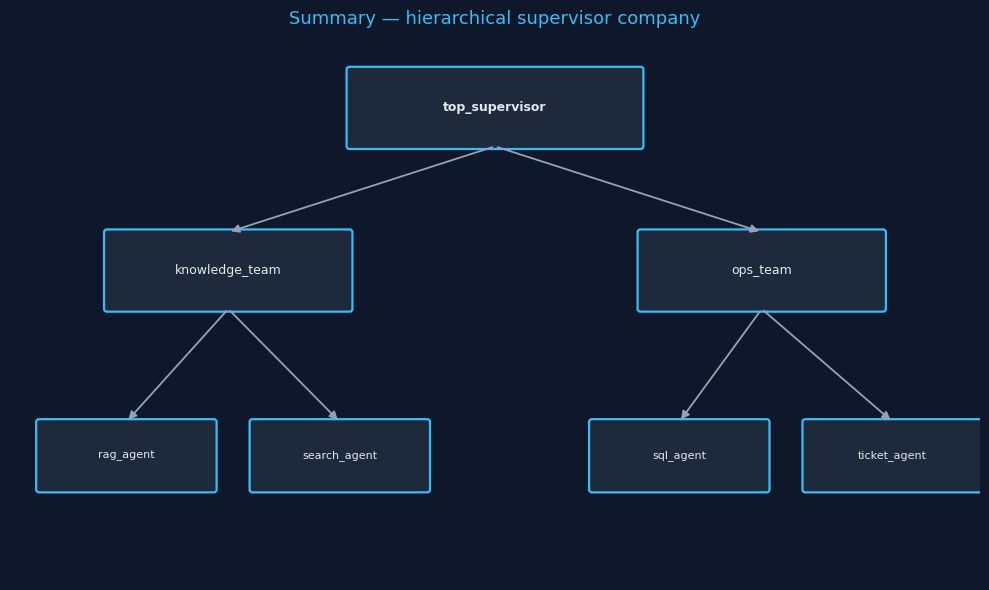

In [22]:
from _nb03_diagrams import draw_summary_tree
draw_summary_tree()
